<a href="https://colab.research.google.com/github/Srishti160/Oral-Cancer-Detection/blob/tempo/Oral_Cancer_DataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Pre-processing using RamanSPY

In [ ]:
!pip install ramanspy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 16.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.9/211.9 kB 18.7 MB/s eta 0:00:00
  Created wheel for pysptools: filename=pysptools-0.15.0-py3-none-any.whl size=8133730 sha256=bace81f6bff06830dc2471cd3f0f1cded428750817dd16a0a9bf4f118df8210f
  Stored in directory: /root/.cache/pip/wheels/cf/fc/d3/0af346dd85827b7411342d0b44507a59d637a995c7e0f00fa6
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=090f9745b34f0eabab33aa06c1e7a95b4fde170826192c62d5daf14551e86d58
  Stored in directory: /root/.cache/pip/wheels/40/b3/0f/a40dbd1c6861731779f62cc4babcb234387e11d697df70ee97
Successfully built pysptools wget


In [ ]:
import matplotlib.pyplot as plt
import random
import numpy as np

import ramanspy

In [ ]:
random.seed(42)

In [ ]:
colors = plt.cm.get_cmap()(np.linspace(0, 1, 4))

/tmp/ipython-input-2975927690.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap()(np.linspace(0, 1, 4))


In [ ]:
plt.rcParams['figure.figsize'] = [4, 2]

In [ ]:
import pandas as pd
import ramanspy

file_path = "Oral_cancer (1).csv"  # <-- change path if needed
raw_df = pd.read_csv(file_path)

# Raman shifts are in row 0, starting from Var0
raman_shifts = raw_df.iloc[0, 2:].astype(float).values

# All spectra from row 1 onward
spectra_data = raw_df.iloc[1:, 2:].astype(float).values

# Create RamanSPy Spectrum objects
raman_spectra_objects = [
    ramanspy.Spectrum(spectrum, raman_shifts) for spectrum in spectra_data
]


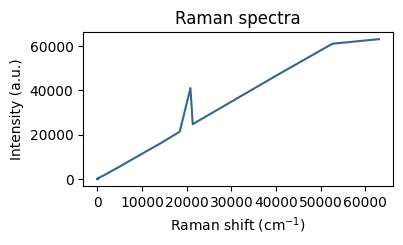

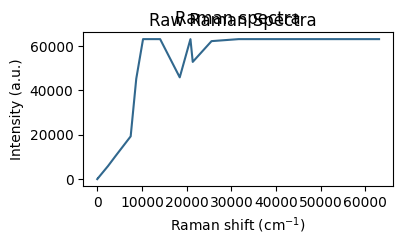

In [ ]:
random_indices = random.sample(range(len(raman_spectra_objects)), 2)
random_spectra = [raman_spectra_objects[i] for i in random_indices]

ramanspy.plot.spectra(random_spectra, color=colors[1], plot_type='separate')
plt.suptitle("Raw Raman Spectra")
plt.show()


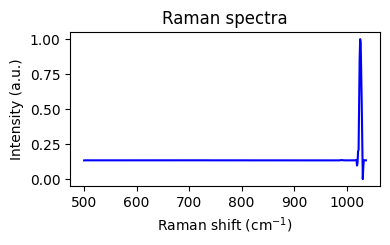

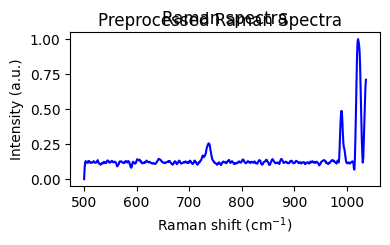

In [ ]:
import matplotlib.pyplot as plt
import random
import numpy as np
import pandas as pd
import ramanspy

file_path = "Oral_cancer (1).csv"
raw_df = pd.read_csv(file_path)

# Raman shifts from column names
raman_shifts = np.array([float(col.replace("Var", "")) for col in raw_df.columns[2:]])

# All spectra (intensity values)
spectra_data = raw_df.iloc[:, 2:].astype(float).values

# Create Spectrum objects
raman_spectra_objects = [
    ramanspy.Spectrum(spectrum, raman_shifts) for spectrum in spectra_data
]

# Pick random spectra
random_indices = random.sample(range(len(raman_spectra_objects)), 2)
random_spectra = [raman_spectra_objects[i] for i in random_indices]

# Preprocessing pipeline
cropper = ramanspy.preprocessing.misc.Cropper(region=(500, 2000))
pipe = ramanspy.preprocessing.protocols.Pipeline([
    cropper,
    ramanspy.preprocessing.despike.WhitakerHayes(),
    ramanspy.preprocessing.denoise.SavGol(window_length=9, polyorder=3),
    ramanspy.preprocessing.baseline.ASPLS(),
    ramanspy.preprocessing.normalise.MinMax(pixelwise=True),
])

# Apply pipeline
preprocessed_spectra = pipe.apply(random_spectra)

# Plot
_ = ramanspy.plot.spectra(preprocessed_spectra, color='blue', plot_type='separate')
plt.suptitle("Preprocessed Raman Spectra")
plt.show()


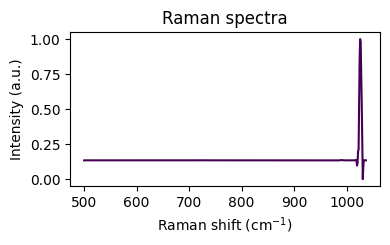

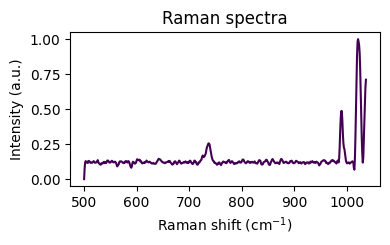

In [ ]:
# preprocess the spectra
pipe = ramanspy.preprocessing.protocols.Pipeline([
    cropper,
    ramanspy.preprocessing.despike.WhitakerHayes(),
    ramanspy.preprocessing.denoise.SavGol(window_length=9, polyorder=3),
    ramanspy.preprocessing.baseline.ASPLS(),
    ramanspy.preprocessing.normalise.MinMax(pixelwise=True),
])
preprocessed_spectra = pipe.apply(random_spectra)

# plot the results
_ = ramanspy.plot.spectra(preprocessed_spectra, color=colors[0], plot_type='separate')


In [ ]:
import pandas as pd

# Load the data into a DataFrame named 'df'
df = pd.read_csv("Oral_cancer (1).csv")

# Now this will work
print(df.columns)

Index(['raman_type', 'labels', 'Var0', 'Var1', 'Var2', 'Var3', 'Var4', 'Var5',
       'Var6', 'Var7',
       ...
       'Var1028', 'Var1029', 'Var1030', 'Var1031', 'Var1032', 'Var1033',
       'Var1034', 'Var1035', 'Var1036', 'Var1037'],
      dtype='object', length=1040)


In [ ]:
# Features (all Var columns)
X = df.drop(columns=['labels', 'raman_type'])

# Target
y = df['labels']

# Train/Val/Test split
from sklearn.model_selection import train_test_split

# First split into train+val and test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Then split train+val into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)  # 0.25 x 0.8 = 0.2 of total

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (249, 1038)
Validation shape: (83, 1038)
Test shape: (84, 1038)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import numpy as np

# Load full data and create binary labels
df = pd.read_csv("Oral_cancer (1).csv")
df['binary_label'] = df['labels'].apply(lambda x: 0 if x == 0 else 1)

# Features & target
X = df.drop(columns=['raman_type', 'labels', 'binary_label'])
y = df['binary_label']

# Train/Val/Test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print("Value counts of y_val:")
print(y_val.value_counts())

# --- Corrected Function to compute metrics ---
def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    # Check if the validation set contains only a single class
    if len(y_val.value_counts()) < 2:
        print(f"Warning: The validation set for {model.__class__.__name__} contains only one class. Metrics will be undefined.")
        acc = accuracy_score(y_val, preds)
        sens = np.nan
        spec = np.nan
    else:
        acc = accuracy_score(y_val, preds)
        sens = recall_score(y_val, preds)
        tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    return acc, sens, spec

# Models to test
models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Evaluate
results = []
for name, model in models.items():
    acc, sens, spec = evaluate_model(model, X_train, y_train, X_val, y_val)
    results.append([name, acc, sens, spec])

# Show results
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Sensitivity", "Specificity"])
print(results_df)

Value counts of y_val:
binary_label
0    83
Name: count, dtype: int64


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 17.1 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 600)
    max_depth = trial.suggest_int('max_depth', 3, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    return np.mean(score)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)
print("Best RF params:", study_rf.best_params)
print("Best RF CV Accuracy:", study_rf.best_value)


[I 2025-08-14 07:49:29,152] A new study created in memory with name: no-name-b144e12b-6916-4dfd-ad85-cca2e92e1f9c
[I 2025-08-14 07:50:48,641] Trial 0 finished with value: 0.9391297560105268 and parameters: {'n_estimators': 527, 'max_depth': 24, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9391297560105268.
[I 2025-08-14 07:51:15,221] Trial 1 finished with value: 0.9367679200677996 and parameters: {'n_estimators': 482, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.9391297560105268.
[I 2025-08-14 07:51:55,666] Trial 2 finished with value: 0.8584359248851421 and parameters: {'n_estimators': 370, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9391297560105268.
[I 2025-08-14 07:53:15,612] Trial 3 finished with value: 0.9372418484321334 and parameters: {'n_estimators': 572, 'max_depth': 19, 'mi

Best RF params: {'n_estimators': 553, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2'}
Best RF CV Accuracy: 0.9429033409161871


In [ ]:
from xgboost import XGBClassifier

def objective_xgb(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 600)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    reg_lambda = trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
    reg_alpha = trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True)

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_lambda=reg_lambda,
        reg_alpha=reg_alpha,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False
    )

    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    return np.mean(score)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)
print("Best XGB params:", study_xgb.best_params)
print("Best XGB CV Accuracy:", study_xgb.best_value)


[I 2025-08-14 08:11:01,680] A new study created in memory with name: no-name-555298d0-3fe6-46a1-8347-c39e5e5323fb
[I 2025-08-14 08:11:37,695] Trial 0 finished with value: 0.95045831660645 and parameters: {'n_estimators': 145, 'max_depth': 3, 'learning_rate': 0.2792154170739257, 'subsample': 0.8210050222306335, 'colsample_bytree': 0.7918697674057054, 'reg_lambda': 0.0035091822428326694, 'reg_alpha': 1.0289535060768706}. Best is trial 0 with value: 0.95045831660645.
[I 2025-08-14 08:16:00,932] Trial 1 finished with value: 0.9443251260091886 and parameters: {'n_estimators': 253, 'max_depth': 8, 'learning_rate': 0.01875926322434637, 'subsample': 0.9265098233985667, 'colsample_bytree': 0.9482448189046799, 'reg_lambda': 0.6764751627059841, 'reg_alpha': 0.04797298237707241}. Best is trial 0 with value: 0.95045831660645.
[I 2025-08-14 08:18:50,064] Trial 2 finished with value: 0.9518722958205095 and parameters: {'n_estimators': 494, 'max_depth': 7, 'learning_rate': 0.07679969921995218, 'subsam

Best XGB params: {'n_estimators': 312, 'max_depth': 4, 'learning_rate': 0.09028527444734653, 'subsample': 0.8927830954244955, 'colsample_bytree': 0.7295836702253653, 'reg_lambda': 0.10019792229508748, 'reg_alpha': 0.009119411559109801}
Best XGB CV Accuracy: 0.9584760694054151


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

# Train RF
best_rf = RandomForestClassifier(**study_rf.best_params, class_weight='balanced', random_state=42)
best_rf.fit(X_train, y_train)
rf_preds = best_rf.predict(X_test)

# Train XGB
best_xgb = XGBClassifier(**study_xgb.best_params, eval_metric='logloss', random_state=42, use_label_encoder=False)
best_xgb.fit(X_train, y_train)
xgb_preds = best_xgb.predict(X_test)

# Metrics function
def evaluate_model(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred)
    spec = tn / (tn + fp)
    return acc, sens, spec

# Results
rf_acc, rf_sens, rf_spec = evaluate_model(y_test, rf_preds)
xgb_acc, xgb_sens, xgb_spec = evaluate_model(y_test, xgb_preds)

# Summary table
import pandas as pd
results_df = pd.DataFrame({
    'Model': ['RandomForest', 'XGBoost'],
    'Accuracy': [rf_acc, xgb_acc],
    'Sensitivity': [rf_sens, xgb_sens],
    'Specificity': [rf_spec, xgb_spec]
})
print(results_df)


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [09:55:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


          Model  Accuracy  Sensitivity  Specificity
0  RandomForest  0.947666     0.978836     0.821429
1       XGBoost  0.960396     0.994709     0.821429


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Assuming you have X_train, X_val, y_train, y_val ready

# Initialize RF with best parameters
rf = RandomForestClassifier(
    n_estimators=553,
    max_depth=20,
    min_samples_split=6,
    min_samples_leaf=3,
    max_features='log2',
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predictions
y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Random Forest Training Accuracy: {train_accuracy:.4f}")
print(f"Random Forest Validation Accuracy: {val_accuracy:.4f}")


Random Forest Training Accuracy: 0.9920
Random Forest Validation Accuracy: 0.9321


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# Initialize XGB with best parameters
xgb_model = xgb.XGBClassifier(
    n_estimators=312,
    max_depth=4,
    learning_rate=0.090285,
    subsample=0.89278,
    colsample_bytree=0.72958,
    reg_lambda=0.1002,
    reg_alpha=0.0091,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

# Predictions
y_train_pred = xgb_model.predict(X_train)
y_val_pred = xgb_model.predict(X_val)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"XGBoost Training Accuracy: {train_accuracy:.4f}")
print(f"XGBoost Validation Accuracy: {val_accuracy:.4f}")


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:07:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Training Accuracy: 1.0000
XGBoost Validation Accuracy: 0.9675


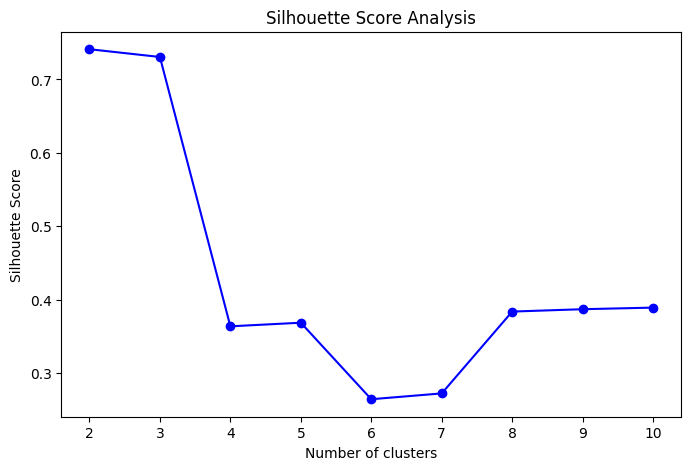

Optimal number of clusters: 2
Cluster Sizes:
 Cluster
1    2615
0     211
Name: count, dtype: int64
Cluster Centers:
        Var0      Var1     Var2      Var3      Var4      Var5      Var6  \
0 -0.384054 -0.367827 -0.39807 -0.395147 -0.090174 -0.001902  0.001256   
1  0.030989  0.029679  0.03212  0.031884  0.007276  0.000153 -0.000101   

       Var7      Var8      Var9  ...   Var1028   Var1029   Var1030   Var1031  \
0  0.135845  0.549829  0.957560  ...  0.693585 -1.286350 -1.360075 -1.398428   
1 -0.010961 -0.044365 -0.077264  ... -0.055964  0.103793  0.109742  0.112837   

    Var1032   Var1033   Var1034   Var1035   Var1036   Var1037  
0 -1.256572 -1.255838 -1.151998 -2.246204 -2.239951 -2.245482  
1  0.101391  0.101332  0.092953  0.181242  0.180738  0.181184  

[2 rows x 1038 columns]


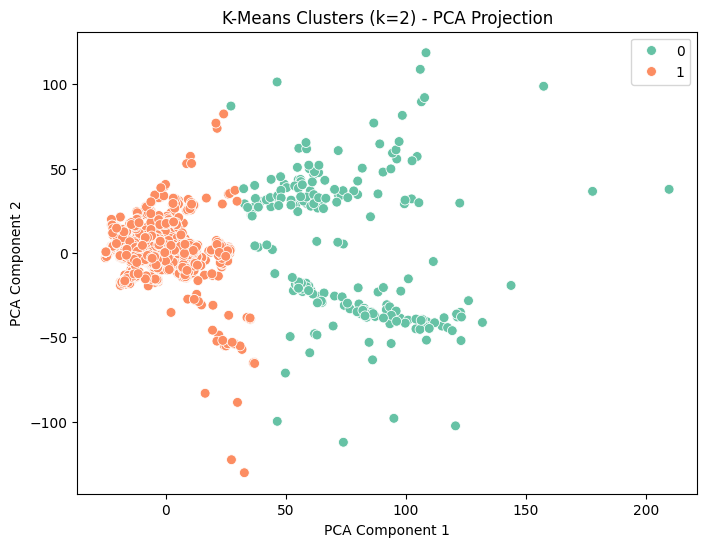

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Step 1: Prepare Data
# -------------------------
# Assuming X_train, X_val are your feature sets
X = pd.concat([X_train, X_val], axis=0)  # combine train and validation sets
X_scaled = StandardScaler().fit_transform(X)  # scale features

# -------------------------
# Step 2: Determine Optimal Number of Clusters
# -------------------------
K = range(2, 11)  # test 2 to 10 clusters
sil_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(K, sil_scores, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Analysis')
plt.show()

# Choose optimal k (the one with the highest silhouette score)
optimal_k = K[sil_scores.index(max(sil_scores))]
print(f"Optimal number of clusters: {optimal_k}")

# -------------------------
# Step 3: Fit K-Means
# -------------------------
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataset
X_clustered = X.copy()
X_clustered['Cluster'] = cluster_labels

# -------------------------
# Step 4: Analyze Clusters
# -------------------------
# Cluster sizes
print("Cluster Sizes:\n", X_clustered['Cluster'].value_counts())

# Cluster centers (in scaled space)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
print("Cluster Centers:\n", centers)

# -------------------------
# Step 5: Visualize Clusters with PCA
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette='Set2', s=50)
plt.title(f'K-Means Clusters (k={optimal_k}) - PCA Projection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()
